# GARCH Volatility Modeling & VaR Backtesting (with CVaR Forecasting): VCB

I wanted to see if I could actually build a working risk model, not just fit a GARCH model and
call it done. So the plan here is: check the return series actually needs GARCH (don't just
assume it), fit the model, use it to forecast VaR/CVaR day by day, and then check with real
statistical tests whether those VaR numbers can be trusted.

**Data:** 40 VN-listed equities, daily closing prices, 2023-03-31 to 2026-03-31 (747 trading days)

**Question:** Can a GARCH(1,1) model with Student-t errors produce well-calibrated one-day-ahead
Value-at-Risk forecasts for VCB, and does that calibration hold up across the broader VN equity
universe?



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.precision", 4)
plt.rcParams["figure.dpi"] = 110

TRADING_DAYS_PER_YEAR = 252


## 1. Data pipeline


In [2]:
df = pd.read_csv("../data/vn_stock_prices_raw.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")

vcb_price = df["VCB"]
log_ret = (np.log(vcb_price / vcb_price.shift(1)).dropna()) * 100  # in percent

print(f"n = {len(log_ret)} trading days "
      f"({log_ret.index.min().date()} -> {log_ret.index.max().date()})")
print(f"Mean: {log_ret.mean():.4f}%   Std Dev: {log_ret.std():.4f}%")
print(f"Skewness: {log_ret.skew():.4f}   Kurtosis (excess): {log_ret.kurtosis():.4f}")


n = 746 trading days (2023-04-03 -> 2026-03-31)
Mean: -0.0059%   Std Dev: 1.5007%
Skewness: -0.5869   Kurtosis (excess): 13.1873


## 2. Descriptive statistics & distributional tests

Three formal checks before modeling:

- **Augmented Dickey-Fuller (ADF) test** : tests whether the return series is stationary (no
  unit root / trend). GARCH modeling assumes a stationary series with a constant unconditional
  mean.
- **Jarque-Bera test**: tests whether skewness and kurtosis match a normal distribution.
- **ARCH-LM test**: tests whether squared returns are autocorrelated (large moves cluster
  in time).


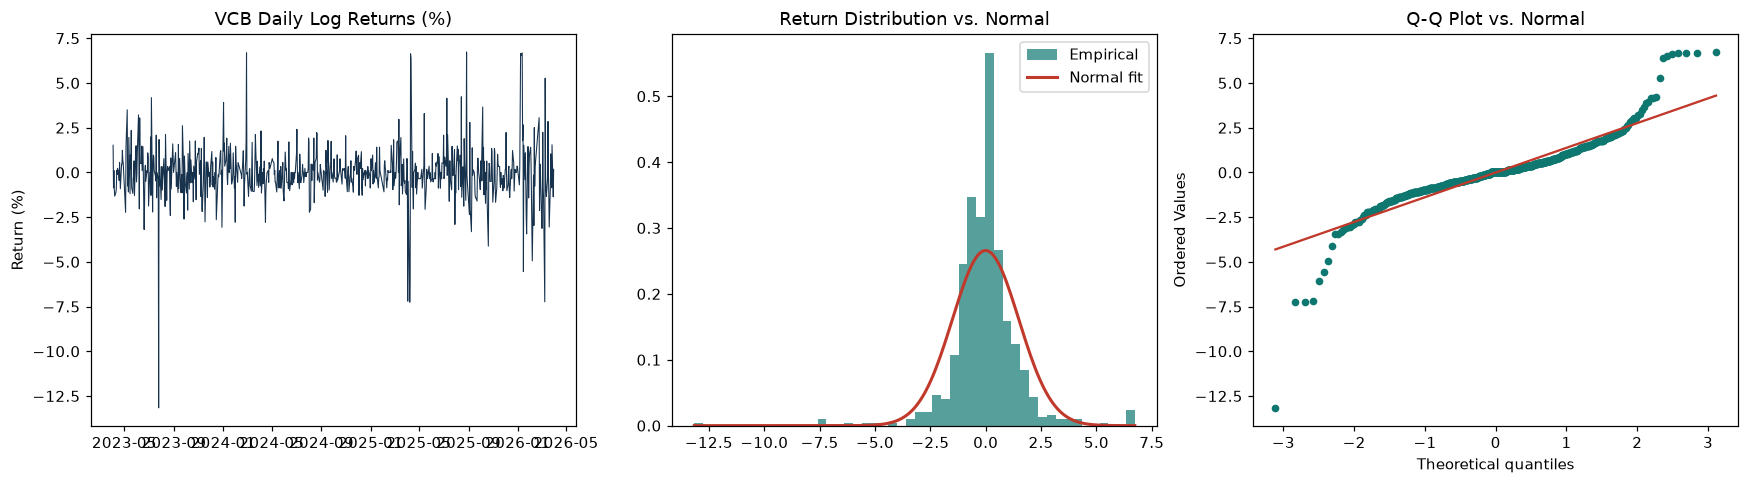

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(log_ret.index, log_ret.values, linewidth=0.7, color="#17324D")
axes[0].set_title("VCB Daily Log Returns (%)")
axes[0].set_ylabel("Return (%)")

axes[1].hist(log_ret, bins=50, density=True, color="#0E7770", alpha=0.7, label="Empirical")
x = np.linspace(log_ret.min(), log_ret.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, log_ret.mean(), log_ret.std()), color="#C0392B",
             linewidth=2, label="Normal fit")
axes[1].set_title("Return Distribution vs. Normal")
axes[1].legend()

stats.probplot(log_ret, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot vs. Normal")
axes[2].get_lines()[0].set_markerfacecolor("#0E7770")
axes[2].get_lines()[0].set_markeredgecolor("#0E7770")
axes[2].get_lines()[0].set_markersize(4)
axes[2].get_lines()[1].set_color("#C0392B")

plt.tight_layout()
plt.savefig("../outputs/return_distribution_qq.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading the Q-Q plot:** If returns were normally distributed, the points would follow the red line. The clear deviations at both tails suggest more extreme returns than predicted by a normal distribution, providing visual evidence of fat tails and supporting the Jarque-Bera test result.


In [4]:
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(log_ret, autolag="AIC")
print(f"ADF statistic: {adf_stat:.4f}   p-value: {adf_p:.6f}   lags used: {adf_lags}")
print(f"Critical values: {adf_crit}")
print("-> Reject unit root (series is stationary)" if adf_p < 0.05
      else "-> Cannot reject unit root (series may be non-stationary)")


ADF statistic: -25.6220   p-value: 0.000000   lags used: 0
Critical values: {'1%': np.float64(-3.4391580196774494), '5%': np.float64(-2.8654273226340554), '10%': np.float64(-2.5688400274762397)}
-> Reject unit root (series is stationary)


In [5]:
jb_stat, jb_p = stats.jarque_bera(log_ret)
print(f"Jarque-Bera: statistic={jb_stat:.2f}, p-value={jb_p:.6f}")
print("-> Reject normality" if jb_p < 0.05 else "-> Cannot reject normality")

lm_stat, lm_p, _, _ = het_arch(log_ret, nlags=5)
print(f"\nARCH-LM (5 lags, on raw returns): statistic={lm_stat:.2f}, p-value={lm_p:.6f}")
print("-> Significant volatility clustering" if lm_p < 0.05 else "-> No significant ARCH effects")



Jarque-Bera: statistic=5369.54, p-value=0.000000
-> Reject normality

ARCH-LM (5 lags, on raw returns): statistic=39.00, p-value=0.000000
-> Significant volatility clustering


## 3. GARCH(1,1): Student-t vs. Normal errors

$$\sigma_t^2 = \omega + \alpha \, \epsilon_{t-1}^2 + \beta \, \sigma_{t-1}^2$$

Given the heavy tails found above, we fit **both** a Normal-GARCH and a Student-t-GARCH and
compare them on log-likelihood, AIC, and BIC -- rather than just asserting Student-t is better,
we check.


In [6]:
normal_fit = arch_model(log_ret, mean="Constant", vol="Garch", p=1, q=1, dist="normal").fit(disp="off")
t_fit = arch_model(log_ret, mean="Constant", vol="Garch", p=1, q=1, dist="t").fit(disp="off")

comparison = pd.DataFrame({
    "Normal-GARCH": {"Log-Likelihood": normal_fit.loglikelihood, "AIC": normal_fit.aic, "BIC": normal_fit.bic},
    "Student-t-GARCH": {"Log-Likelihood": t_fit.loglikelihood, "AIC": t_fit.aic, "BIC": t_fit.bic},
})
comparison


,Normal-GARCH,Student-t-GARCH
Log-Likelihood,-1292.1792,-1169.5817
AIC,2592.3584,2349.1635
BIC,2610.8173,2372.2371


Lower AIC/BIC and higher log-likelihood favor Student-t-GARCH if the table above shows it winning
on all three -- which is the empirical justification (not just a theoretical assumption) for using
Student-t errors from here on.


In [7]:
res = t_fit
print(res.summary())
print(f"\nconvergence_flag = {res.convergence_flag} (0 = converged)")


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          VCB   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1169.58
Distribution:      Standardized Student's t   AIC:                           2349.16
Method:                  Maximum Likelihood   BIC:                           2372.24
                                              No. Observations:                  746
Date:                      Thu, Sep 03 2026   Df Residuals:                      745
Time:                              14:21:04   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

$\alpha + \beta$ close to but below 1 is standard covariance-stationary GARCH(1,1) behavior
(finite long-run variance); values very close to 1 imply highly persistent volatility shocks
that decay slowly. The estimated $\nu$ (degrees of freedom) confirms independently how
fat-tailed VCB's returns are.


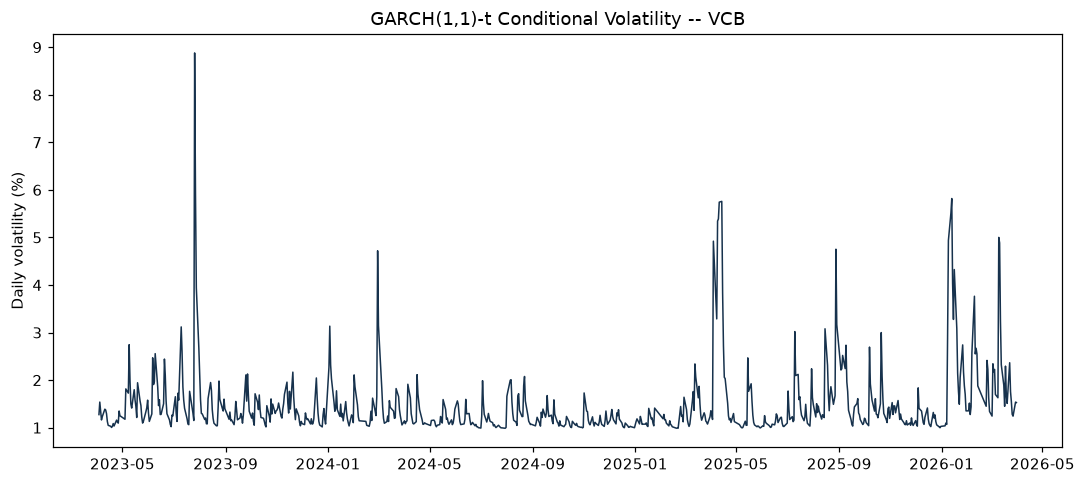

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(log_ret.index, res.conditional_volatility, color="#17324D", linewidth=1)
ax.set_title("GARCH(1,1)-t Conditional Volatility -- VCB")
ax.set_ylabel("Daily volatility (%)")
plt.tight_layout()
plt.savefig("../outputs/garch_conditional_volatility.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Walk-forward VaR / CVaR forecasting




In [9]:
def forecast_var_cvar(fitted, alpha_levels=(0.05, 0.01)):
    """Given a fitted arch model, return next-day VaR and CVaR at each alpha level."""
    forecast = fitted.forecast(horizon=1, reindex=False)
    sigma_next = np.sqrt(forecast.variance.values[-1, 0])
    mu_next = fitted.params["mu"]
    nu = fitted.params["nu"]
    scale = np.sqrt((nu - 2) / nu)

    var_out, cvar_out = {}, {}
    for a in alpha_levels:
        t_q = stats.t.ppf(a, df=nu)
        var_out[a] = mu_next + sigma_next * t_q * scale

        es_z = -(1 / a) * stats.t.pdf(t_q, df=nu) * (nu + t_q ** 2) / (nu - 1)
        cvar_out[a] = mu_next + sigma_next * scale * es_z

    return var_out, cvar_out


def run_var_backtest(returns, window=500, alpha_levels=(0.05, 0.01), verbose=False):
    """
    Walk-forward VaR/CVaR backtest with a DAILY refit (see note above on why this
    replaces the earlier 'refit every N days, forecast every day' approach).
    VaR and CVaR are reported as return thresholds (negative = losses), not as
    positive loss magnitudes.
    """
    var_out = {a: [] for a in alpha_levels}
    cvar_out = {a: [] for a in alpha_levels}
    actual_out, dates_out = [], []

    for t in range(window, len(returns)):
        train = returns.iloc[t - window:t]
        fitted = arch_model(train, mean="Constant", vol="Garch", p=1, q=1, dist="t").fit(disp="off")

        v, c = forecast_var_cvar(fitted, alpha_levels)
        for a in alpha_levels:
            var_out[a].append(v[a])
            cvar_out[a].append(c[a])

        actual_out.append(returns.iloc[t])
        dates_out.append(returns.index[t])
        if verbose and (t - window) % 50 == 0:
            print(f"  ...{t - window}/{len(returns) - window} days done")

    cols = {"actual_return": actual_out}
    for a in alpha_levels:
        label = f"{int((1 - a) * 100)}"
        cols[f"VaR_{label}"] = var_out[a]
        cols[f"CVaR_{label}"] = cvar_out[a]
    return pd.DataFrame(cols, index=pd.DatetimeIndex(dates_out))


print("Running DAILY-refit walk-forward VaR/CVaR backtest for VCB (~10-15s)...")
backtest = run_var_backtest(log_ret, window=500)
print(f"Backtest window: {backtest.index.min().date()} -> {backtest.index.max().date()} "
      f"({len(backtest)} out-of-sample forecasts)")
backtest.head()


Running DAILY-refit walk-forward VaR/CVaR backtest for VCB (~10-15s)...
Backtest window: 2025-04-03 -> 2026-03-31 (246 out-of-sample forecasts)


,actual_return,VaR_95,CVaR_95,VaR_99,CVaR_99
2025-04-03,-7.1973,-1.3945,-2.0682,-2.4150,-3.3245
2025-04-04,-0.4988,-2.0705,-3.1958,-3.7410,-5.3854
2025-04-08,-7.2571,-1.9422,-2.9887,-3.4981,-5.0186
2025-04-09,-6.0961,-2.8511,-4.4945,-5.2651,-7.7555
2025-04-10,6.6323,-3.9527,-6.3329,-7.4209,-11.1241


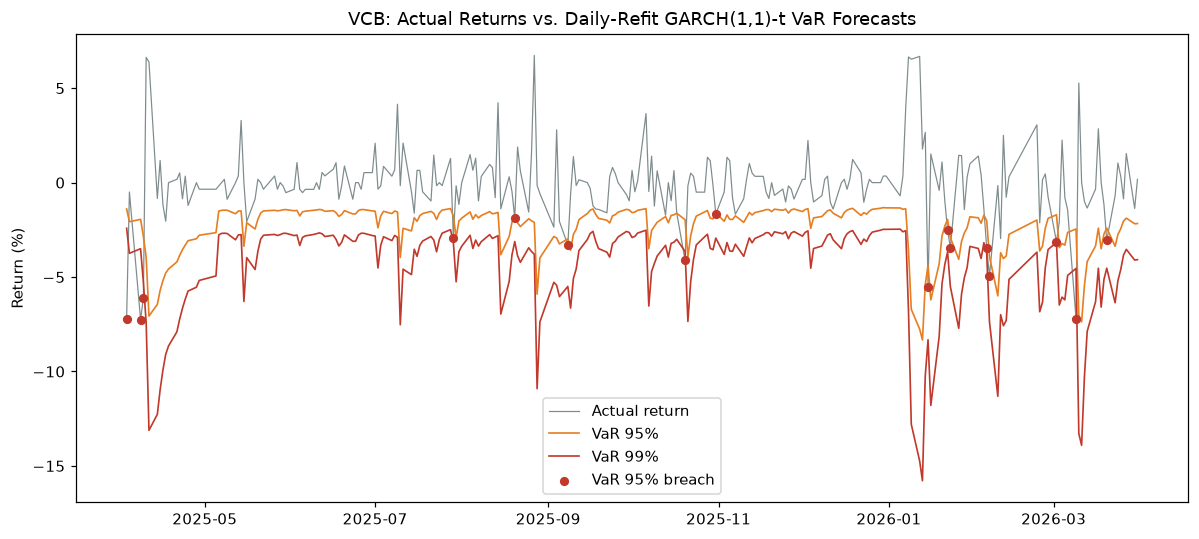

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(backtest.index, backtest["actual_return"], color="#7F8C8D", linewidth=0.8, label="Actual return")
ax.plot(backtest.index, backtest["VaR_95"], color="#E67E22", linewidth=1.1, label="VaR 95%")
ax.plot(backtest.index, backtest["VaR_99"], color="#C0392B", linewidth=1.1, label="VaR 99%")

breaches_95 = backtest["actual_return"] < backtest["VaR_95"]
ax.scatter(backtest.index[breaches_95], backtest["actual_return"][breaches_95],
           color="#C0392B", s=25, zorder=5, label="VaR 95% breach")

ax.set_title("VCB: Actual Returns vs. Daily-Refit GARCH(1,1)-t VaR Forecasts")
ax.set_ylabel("Return (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/var_backtest_vcb.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Backtesting: Kupiec test + Christoffersen independence test

**Kupiec unconditional coverage test** -- checks whether the total breach rate matches alpha.
Implemented to handle the edge case of zero breaches (a real possibility at the 99% level in a
~250-day sample) using the standard $0 \log(\cdot) = 0$ convention for the null log-likelihood's
$x \log(\alpha)$ term, rather than returning an undefined result.

**Christoffersen independence test** -- Kupiec only checks the *total count* of breaches, not
whether they cluster in time. A model could have exactly the right number of breaches but have
them arrive in a cluster (a sign the model isn't tracking volatility changes well) and Kupiec
alone would not catch that. This test checks whether a breach today is independent of a breach
yesterday.

**Conditional coverage test** -- combines both into a single joint test ($\chi^2$, 2 degrees of
freedom).


In [11]:
def kupiec_test(actual_returns, var_forecasts, alpha):
    """Kupiec (1995) unconditional coverage test, with safe handling of x=0 or x=n."""
    breaches = (actual_returns < var_forecasts).astype(int)
    n, x = len(breaches), int(breaches.sum())
    pi_hat = x / n

    def xlogy_safe(a, b):
        return 0.0 if a == 0 else a * np.log(b)

    logL_null = xlogy_safe(x, alpha) + xlogy_safe(n - x, 1 - alpha)
    if x == 0:
        logL_alt = n * np.log(1 - pi_hat)
    elif x == n:
        logL_alt = n * np.log(pi_hat)
    else:
        logL_alt = x * np.log(pi_hat) + (n - x) * np.log(1 - pi_hat)

    lr_uc = -2 * (logL_null - logL_alt)
    p_uc = 1 - stats.chi2.cdf(lr_uc, df=1)
    return x, n, lr_uc, p_uc


def christoffersen_independence_test(actual_returns, var_forecasts):
    """
    Christoffersen (1998) independence test on the breach indicator sequence.
    Under H0 (independence), pi01 = pi11 = pi2. Substituting this into the
    unrestricted likelihood and simplifying (verified symbolically) gives:
        L0 = (1-pi2)^(n00+n10) * pi2^(n01+n11)
    i.e. the restricted-likelihood exponents group transitions by their
    ENDING state (n00+n10, n01+n11), not their starting state.
    Returns NaN if there are no transitions from one of the two states
    (independence is not meaningfully testable in that case, not a code error).
    """
    breaches = (actual_returns < var_forecasts).astype(int).values
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(breaches)):
        prev, curr = breaches[i - 1], breaches[i]
        if prev == 0 and curr == 0: n00 += 1
        elif prev == 0 and curr == 1: n01 += 1
        elif prev == 1 and curr == 0: n10 += 1
        elif prev == 1 and curr == 1: n11 += 1

    n0_start, n1_start = n00 + n01, n10 + n11  # transitions starting from state 0 / 1
    if n0_start == 0 or n1_start == 0:
        return np.nan, np.nan

    pi01 = n01 / n0_start
    pi11 = n11 / n1_start
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    def xlogy_safe(a, b):
        if a == 0:
            return 0.0
        return a * np.log(b) if b > 0 else -np.inf

    logL_restricted = xlogy_safe(n00 + n10, 1 - pi) + xlogy_safe(n01 + n11, pi)
    logL_unrestricted = (xlogy_safe(n00, 1 - pi01) + xlogy_safe(n01, pi01)
                          + xlogy_safe(n10, 1 - pi11) + xlogy_safe(n11, pi11))

    lr_ind = -2 * (logL_restricted - logL_unrestricted)
    p_ind = 1 - stats.chi2.cdf(lr_ind, df=1)
    return lr_ind, p_ind


def backtest_report(actual_returns, var_forecasts, alpha, label):
    x, n, lr_uc, p_uc = kupiec_test(actual_returns, var_forecasts, alpha)
    lr_ind, p_ind = christoffersen_independence_test(actual_returns, var_forecasts)
    lr_cc = lr_uc + lr_ind if not np.isnan(lr_ind) else np.nan
    p_cc = 1 - stats.chi2.cdf(lr_cc, df=2) if not np.isnan(lr_cc) else np.nan
    return {
        "level": label, "breaches": x, "n": n, "breach_rate": x / n, "expected_rate": alpha,
        "kupiec_p": p_uc, "christoffersen_p": p_ind, "conditional_coverage_p": p_cc,
    }


results_95 = backtest_report(backtest["actual_return"], backtest["VaR_95"], 0.05, "VaR 95%")
results_99 = backtest_report(backtest["actual_return"], backtest["VaR_99"], 0.01, "VaR 99%")
report = pd.DataFrame([results_95, results_99]).set_index("level")
report


,breaches,n,breach_rate,expected_rate,kupiec_p,christoffersen_p,conditional_coverage_p
level,,,,,,,
VaR 95%,16,246,0.0650,0.05,0.2999,0.0699,0.1131
VaR 99%,5,246,0.0203,0.01,0.1533,0.0579,0.0598


## 8. Extension: does this generalize across all 40 stocks?

Three questions here: (a) do all 40 stocks actually show the same stationary, non-normal,
volatility-clustered behavior that justified using GARCH for VCB in Section 2, not just assumed
by extension; (b) do GARCH(1,1)-t parameters look reasonable across the whole universe; and
(c) does VCB's Section 5 calibration result hold up when the exact same daily-refit backtest is
run on every stock, not just one?

**Convergence is checked explicitly** via `convergence_flag` (0 = converged) rather than just
catching exceptions -- fitting without error is not the same as the optimizer actually converging.


In [12]:
tickers = [c for c in df.columns if c != "VNINDEX"]

print("Running ADF, Jarque-Bera, and ARCH-LM tests across all 40 stocks "
      "(checking the stationarity + GARCH justification holds universe-wide, not just for VCB)...")

dist_test_records = []
for tkr in tickers:
    r = (np.log(df[tkr] / df[tkr].shift(1)).dropna()) * 100
    if len(r) < 200:
        continue
    adf_stat, adf_p, _, _, _, _ = adfuller(r, autolag="AIC")
    jb_stat, jb_p = stats.jarque_bera(r)
    lm_stat, lm_p, _, _ = het_arch(r, nlags=5)
    dist_test_records.append({
        "ticker": tkr, "adf_stat": adf_stat, "adf_p": adf_p,
        "jb_stat": jb_stat, "jb_p": jb_p,
        "lm_stat": lm_stat, "lm_p": lm_p,
    })

dist_tests = pd.DataFrame(dist_test_records).set_index("ticker")
n_stationary = (dist_tests["adf_p"] < 0.05).sum()
n_nonnormal = (dist_tests["jb_p"] < 0.05).sum()
n_arch = (dist_tests["lm_p"] < 0.05).sum()
n_total = len(dist_tests)

print(f"ADF rejects a unit root (series is stationary) for {n_stationary}/{n_total} stocks "
      f"({n_stationary/n_total:.0%})")
print(f"Jarque-Bera rejects normality for {n_nonnormal}/{n_total} stocks "
      f"({n_nonnormal/n_total:.0%})")
print(f"ARCH-LM finds significant volatility clustering for {n_arch}/{n_total} stocks "
      f"({n_arch/n_total:.0%})")

if n_stationary < n_total:
    non_stationary = dist_tests[dist_tests["adf_p"] >= 0.05]
    print(f"\nStocks where a unit root CANNOT be rejected (GARCH's constant-mean assumption "
          f"is questionable for these): {list(non_stationary.index)}")

if n_arch < n_total:
    no_arch = dist_tests[dist_tests["lm_p"] >= 0.05]
    print(f"\nStocks WITHOUT significant ARCH effects at 5 lags (GARCH may be less well "
          f"motivated for these specifically): {list(no_arch.index)}")

dist_tests.to_csv("../outputs/distributional_tests_40stocks.csv")


Running ADF, Jarque-Bera, and ARCH-LM tests across all 40 stocks (checking the stationarity + GARCH justification holds universe-wide, not just for VCB)...
ADF rejects a unit root (series is stationary) for 40/40 stocks (100%)
Jarque-Bera rejects normality for 40/40 stocks (100%)
ARCH-LM finds significant volatility clustering for 35/40 stocks (88%)

Stocks WITHOUT significant ARCH effects at 5 lags (GARCH may be less well motivated for these specifically): ['HCM', 'HAH', 'VSC', 'FPT', 'REE']


In [13]:
records = []

MIN_OBSERVATIONS = 501  # need >=500 for the training window plus >=1 day to forecast

for tkr in tickers:
    r = (np.log(df[tkr] / df[tkr].shift(1)).dropna()) * 100
    if len(r) < MIN_OBSERVATIONS:
        continue
    fit = arch_model(r, mean="Constant", vol="Garch", p=1, q=1, dist="t").fit(disp="off")
    records.append({
        "ticker": tkr,
        "kurtosis": r.kurtosis(),
        "persistence": fit.params["alpha[1]"] + fit.params["beta[1]"],
        "nu_tail": fit.params["nu"],
        "converged": fit.convergence_flag == 0,
    })

cross_section_all = pd.DataFrame(records).set_index("ticker")
n_converged = cross_section_all["converged"].sum()
print(f"GARCH(1,1)-t: convergence_flag == 0 (actually converged) for "
      f"{n_converged}/{len(cross_section_all)} stocks")

# Only use actually-converged fits for the persistence/tail analysis below --
# a non-converged optimizer result shouldn't be treated as a valid estimate.
cross_section = cross_section_all[cross_section_all["converged"]].sort_values("nu_tail")
if n_converged < len(cross_section_all):
    print(f"Excluding {len(cross_section_all) - n_converged} non-converged fit(s) from analysis: "
          f"{list(cross_section_all[~cross_section_all['converged']].index)}")

at_boundary = cross_section[cross_section["persistence"] >= 0.9999]
print(f"\nStocks with persistence (alpha+beta) at or above 0.9999: "
      f"{len(at_boundary)}/{len(cross_section)} ({len(at_boundary)/len(cross_section):.0%})")
print(list(at_boundary.index))


GARCH(1,1)-t: convergence_flag == 0 (actually converged) for 40/40 stocks

Stocks with persistence (alpha+beta) at or above 0.9999: 10/40 (25%)
['KDC', 'TLH', 'CNG', 'KDH', 'VIC', 'DGC', 'CMG', 'VHM', 'GAS', 'VSC']


**Persistence near 1:** A few stocks have persistence close to 1, which means volatility shocks tend to last longer. Since this is close to the GARCH boundary, I would be careful about interpreting it as a stable pattern. The result could also be affected by the sample or model estimation, so more testing would be needed to confirm it.


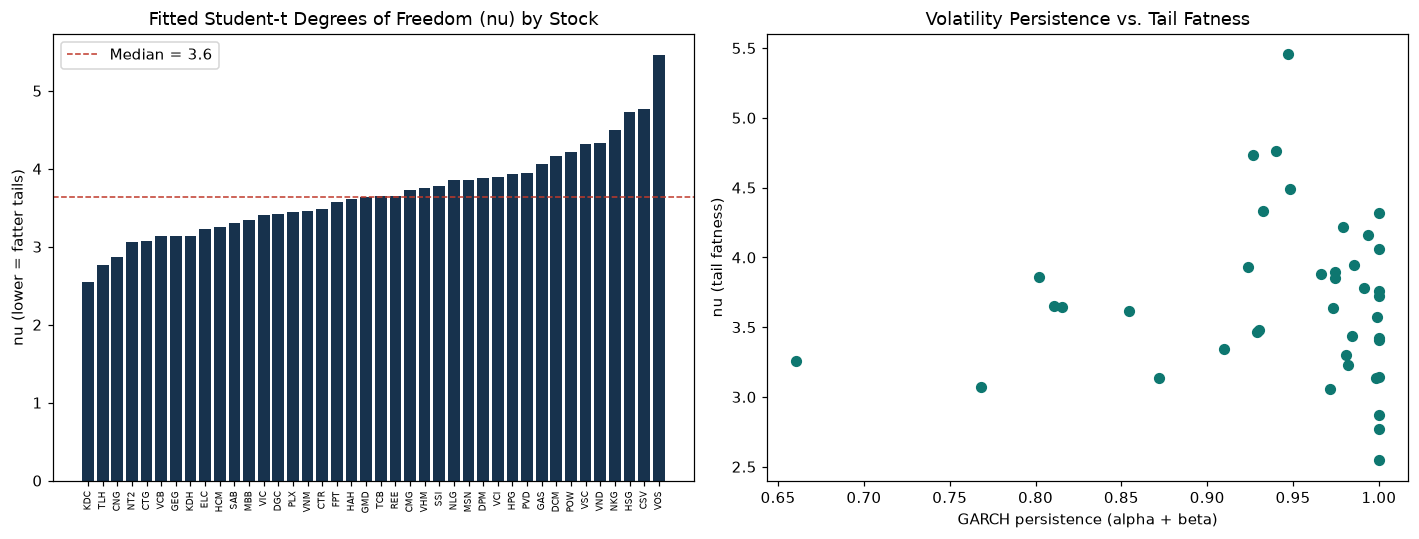

nu range: 2.55 (fattest tails: KDC) to 5.45 (thinnest tails: VOS)
Note: even the highest-nu stock here is still noticeably fatter-tailed than a normal 


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(cross_section.index, cross_section["nu_tail"], color="#17324D")
axes[0].axhline(cross_section["nu_tail"].median(), color="#C0392B", linestyle="--",
                linewidth=1, label=f"Median = {cross_section['nu_tail'].median():.1f}")
axes[0].set_title("Fitted Student-t Degrees of Freedom (nu) by Stock")
axes[0].set_ylabel("nu (lower = fatter tails)")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)
axes[0].legend()

axes[1].scatter(cross_section["persistence"], cross_section["nu_tail"], color="#0E7770", s=40)
axes[1].set_xlabel("GARCH persistence (alpha + beta)")
axes[1].set_ylabel("nu (tail fatness)")
axes[1].set_title("Volatility Persistence vs. Tail Fatness")

plt.tight_layout()
plt.savefig("../outputs/cross_sectional_tail_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"nu range: {cross_section['nu_tail'].min():.2f} (fattest tails: {cross_section['nu_tail'].idxmin()}) "
      f"to {cross_section['nu_tail'].max():.2f} (thinnest tails: {cross_section['nu_tail'].idxmax()})")
print("Note: even the highest-nu stock here is still noticeably fatter-tailed than a normal ")


### Daily-refit VaR backtest across all 40 stocks



In [15]:
import time

print("Running walk-forward VaR backtest for all 40 stocks...")

start_time = time.time()
results = []

for i, ticker in enumerate(tickers, start=1):

    # Calculate daily log returns
    returns = np.log(df[ticker] / df[ticker].shift(1)).dropna() * 100

    # Run daily-refit walk-forward backtest
    backtest = run_var_backtest(returns, window=500)

    # Backtesting results for VaR 95% and 99%
    report_95 = backtest_report(
        backtest["actual_return"],
        backtest["VaR_95"],
        alpha=0.05,
        label="VaR 95%"
    )

    report_99 = backtest_report(
        backtest["actual_return"],
        backtest["VaR_99"],
        alpha=0.01,
        label="VaR 99%"
    )

    results.append({
        "ticker": ticker,

        "breach_95": report_95["breaches"],
        "rate_95": report_95["breach_rate"],
        "kupiec_p_95": report_95["kupiec_p"],
        "cc_p_95": report_95["conditional_coverage_p"],

        "breach_99": report_99["breaches"],
        "rate_99": report_99["breach_rate"],
        "kupiec_p_99": report_99["kupiec_p"],
        "cc_p_99": report_99["conditional_coverage_p"],
    })

    if i % 10 == 0:
        elapsed = time.time() - start_time
        print(f"{i}/{len(tickers)} stocks done ({elapsed:.0f}s elapsed)")

# Combine results
all_summary = pd.DataFrame(results).set_index("ticker")

# Save results
elapsed = time.time() - start_time

all_summary.to_csv("../outputs/full_40stock_var_backtest.csv")

print(f"\nDone in {elapsed:.0f}s ({elapsed / 60:.1f} min)")
print("Results saved to ../outputs/full_40stock_var_backtest.csv")

Running walk-forward VaR backtest for all 40 stocks...
10/40 stocks done (91s elapsed)
20/40 stocks done (195s elapsed)
30/40 stocks done (301s elapsed)
40/40 stocks done (391s elapsed)

Done in 391s (6.5 min)
Results saved to ../outputs/full_40stock_var_backtest.csv


In [16]:
pass_kupiec_95 = (all_summary["kupiec_p_95"] >= 0.05).sum()
pass_kupiec_99 = (all_summary["kupiec_p_99"] >= 0.05).sum()
n = len(all_summary)

# NaN handling: Christoffersen/conditional-coverage p-values can be NaN when a
# stock has zero breaches from one starting state (independence isn't testable,
# not a failure). These are excluded from the denominator rather than silently
# counted as failures (NaN >= 0.05 evaluates to False in pandas, which would
# otherwise misclassify "untestable" as "failed").
valid_cc_95 = all_summary["cc_p_95"].notna()
valid_cc_99 = all_summary["cc_p_99"].notna()
pass_cc_95 = (all_summary.loc[valid_cc_95, "cc_p_95"] >= 0.05).sum()
pass_cc_99 = (all_summary.loc[valid_cc_99, "cc_p_99"] >= 0.05).sum()
n_valid_95, n_valid_99 = valid_cc_95.sum(), valid_cc_99.sum()

print(f"VaR 95%: Kupiec-only pass rate = {pass_kupiec_95}/{n} ({pass_kupiec_95/n:.0%})   "
      f"| Conditional-coverage pass rate = {pass_cc_95}/{n_valid_95} ({pass_cc_95/n_valid_95:.0%})"
      f"{' (' + str(n - n_valid_95) + ' untestable, excluded)' if n_valid_95 < n else ''}")
print(f"VaR 99%: Kupiec-only pass rate = {pass_kupiec_99}/{n} ({pass_kupiec_99/n:.0%})   "
      f"| Conditional-coverage pass rate = {pass_cc_99}/{n_valid_99} ({pass_cc_99/n_valid_99:.0%})"
      f"{' (' + str(n - n_valid_99) + ' untestable, excluded)' if n_valid_99 < n else ''}")

print("\nWorst-calibrated at 95% (by Kupiec p-value):")
all_summary.sort_values("kupiec_p_95").head(10)


VaR 95%: Kupiec-only pass rate = 35/40 (88%)   | Conditional-coverage pass rate = 25/40 (62%)
VaR 99%: Kupiec-only pass rate = 36/40 (90%)   | Conditional-coverage pass rate = 35/40 (88%)

Worst-calibrated at 95% (by Kupiec p-value):


,breach_95,rate_95,kupiec_p_95,cc_p_95,breach_99,rate_99,kupiec_p_99,cc_p_99
ticker,,,,,,,,
KDC,24,0.0976,0.0023,0.0095,6,0.0244,0.0554,0.1372
NLG,24,0.0976,0.0023,0.0019,7,0.0285,0.0175,0.0498
KDH,22,0.0894,0.0102,0.0118,6,0.0244,0.0554,0.1408
VIC,20,0.0813,0.0381,0.0604,3,0.0122,0.7380,0.9225
PVD,20,0.0813,0.0381,0.0211,4,0.0163,0.3655,0.0624
DGC,19,0.0772,0.0685,0.0007,3,0.0122,0.7380,0.9225
VND,19,0.0772,0.0685,0.1659,6,0.0244,0.0554,0.1408
HCM,19,0.0772,0.0685,0.0247,5,0.0203,0.1533,0.3319
CTG,18,0.0732,0.1177,0.0262,5,0.0203,0.1533,0.0598
